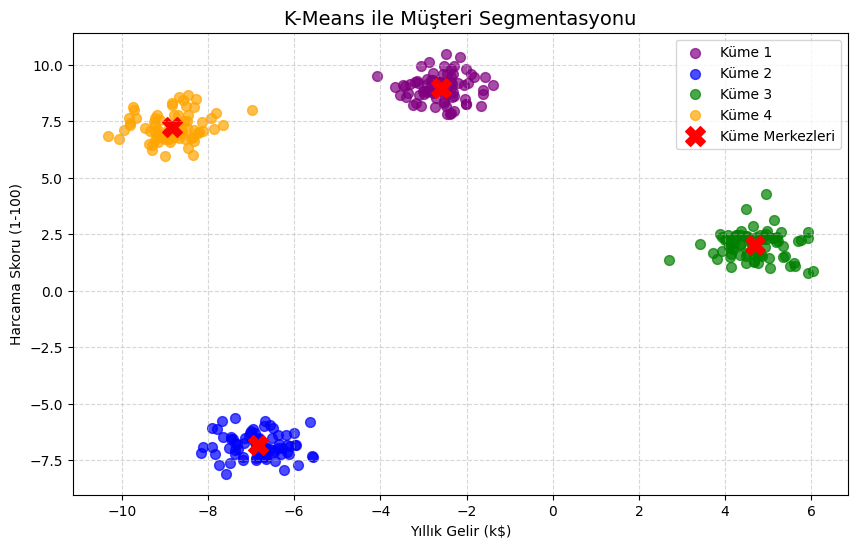

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Sentetik Veri Kümesi Oluşturma
# 300 örnekli, 2 özellikli (örneğin: Gelir ve Harcama Skoru) ve 4 merkezli bir veri üretiyoruz.
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=42)

# Veriyi daha rahat görmek için Pandas DataFrame'e çevirelim
df = pd.DataFrame(X, columns=['Yıllık Gelir (k$)', 'Harcama Skoru (1-100)'])

# 2. Veri Ön İşleme (Ölçeklendirme)
# K-Means mesafe tabanlı bir algoritma olduğu için özelliklerin aynı ölçekte olması hayati önem taşır.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# 3. K-Means Modelini Tanımlama ve Eğtme
# Veriyi 4 kümeye ayırmak istediğimizi belirtiyoruz (n_clusters=4)
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
kmeans.fit(X_scaled)

# Küme merkezlerini ve tahmin edilen etiketleri alıyoruz
labels = kmeans.labels_
centers = kmeans.cluster_centers_

# Tahmin edilen etiketleri DataFrame'imize ekleyelim
df['Cluster'] = labels

# 4. Sonuçları Görselleştirme
plt.figure(figsize=(10, 6))

# Her bir kümeyi farklı renkle çizdirelim
colors = ['purple', 'blue', 'green', 'orange']
for i in range(4):
    cluster_data = df[df['Cluster'] == i]
    # Orijinal ölçekteki verileri çizdiriyoruz, ancak gruplandırmayı modelin tahminine göre yapıyoruz
    plt.scatter(cluster_data['Yıllık Gelir (k$)'], cluster_data['Harcama Skoru (1-100)'],
                c=colors[i], label=f'Küme {i+1}', s=50, alpha=0.7)

# Küme merkezlerini (Centroids) işaretleyelim
# Merkezleri orijinal ölçeğe geri döndürüyoruz ki grafikte doğru yere otursunlar
original_centers = scaler.inverse_transform(centers)
plt.scatter(original_centers[:, 0], original_centers[:, 1],
            c='red', s=200, marker='X', label='Küme Merkezleri')

plt.title('K-Means ile Müşteri Segmentasyonu', fontsize=14)
plt.xlabel('Yıllık Gelir (k$)')
plt.ylabel('Harcama Skoru (1-100)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()